# OpenAI API Models Demo

This notebook demonstrates how to use the `OpenAIModel` class to extract next-token logits and probabilities from OpenAI's API, with a focus on **few-shot prompting for medical multiple-choice questions**.

In [39]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

from src.models.api_models import OpenAIModel

## 1. Basic Usage - Initialize Model

The model will automatically use the `OPENAI_API_KEY` environment variable.

In [40]:
# Initialize the model
model = OpenAIModel(
    model_name="gpt-4o-mini",  # You can also use "gpt-4", "gpt-3.5-turbo", etc.
    top_logprobs=10,  # Get top 10 alternative tokens at each position
    temperature=1.0,
    max_tokens=50  # Limit response length
)

print(f"Model initialized: {model.model_name}")
print(f"Top logprobs to return: {model.top_logprobs}")

Model initialized: gpt-4o-mini
Top logprobs to return: 10


## 2. Few-Shot Prompting for Medical MCQs (MedQA/MedMCQA Style)

Demonstrate few-shot prompting to elicit single-character (A, B, C, D) responses, following the exact prompt format from `medqa_utils.py` and `medmcqa_utils.py`.

In [41]:
# Few-shot examples to teach the model the expected format
few_shot_examples = [
    {
        "question": "A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. What is the most likely diagnosis?",
        "options": {
            "A": "Viral pneumonia",
            "B": "Bacterial pneumonia",
            "C": "Tuberculosis",
            "D": "Lung cancer"
        },
        "answer": "B"
    },
    {
        "question": "Which hormone is primarily responsible for regulating blood glucose levels?",
        "options": {
            "A": "Cortisol",
            "B": "Insulin",
            "C": "Thyroxine",
            "D": "Glucagon"
        },
        "answer": "B"
    },
    {
        "question": "What is the most common cause of hyperthyroidism?",
        "options": {
            "A": "Hashimoto's thyroiditis",
            "B": "Graves' disease",
            "C": "Toxic multinodular goiter",
            "D": "Thyroid adenoma"
        },
        "answer": "B"
    }
]

def create_few_shot_prompt(question, options, num_examples=2, prompt_type='default'):
    """
    Create a few-shot prompt for medical MCQ following MedQA/MedMCQA format.
    
    Args:
        question: The question text
        options: Dictionary with keys A, B, C, D (and optionally E) and option text
        num_examples: Number of few-shot examples to include
        prompt_type: 'default', 'COT', or 'Debiasing'
    """
    prompt = ""
    
    # Add prompt prefix based on type (from medqa_utils.py)
    if prompt_type == 'COT':
        prompt = "Let's think step by step:\n\n"
    elif prompt_type == 'Debiasing':
        prompt = "(Please note that the provided options have been randomly shuffled.)\n\n"
    
    # Add few-shot examples
    for i in range(min(num_examples, len(few_shot_examples))):
        example = few_shot_examples[i]
        prompt += f"Question: {example['question']}\n"
        for option_key in ['A', 'B', 'C', 'D', 'E']:
            if option_key in example['options']:
                prompt += f"{option_key}. {example['options'][option_key]}\n"
        prompt += f"Answer: {example['answer']}\n\n"
    
    # Add the actual question (following exact format from medqa_utils.py line 286-299)
    prompt += f"Question: {question}\n"
    for option_key in ['A', 'B', 'C', 'D', 'E']:
        if option_key in options:
            prompt += f"{option_key}. {options[option_key]}\n"
    prompt += "Answer:"
    
    return prompt

# Test question
test_question = {
    "question": "A 65-year-old patient presents with chest pain radiating to the left arm and diaphoresis. ECG shows ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?",
    "options": {
        "A": "Gastroesophageal reflux disease",
        "B": "Inferior wall myocardial infarction",
        "C": "Costochondritis",
        "D": "Pulmonary embolism"
    }
}

# Create few-shot prompt
few_shot_prompt = create_few_shot_prompt(
    test_question['question'],
    test_question['options'],
    num_examples=2
)

print("Few-Shot Prompt (following MedQA/MedMCQA format):")
print("="*80)
print(few_shot_prompt)
print("="*80)

Few-Shot Prompt (following MedQA/MedMCQA format):
Question: A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. What is the most likely diagnosis?
A. Viral pneumonia
B. Bacterial pneumonia
C. Tuberculosis
D. Lung cancer
Answer: B

Question: Which hormone is primarily responsible for regulating blood glucose levels?
A. Cortisol
B. Insulin
C. Thyroxine
D. Glucagon
Answer: B

Question: A 65-year-old patient presents with chest pain radiating to the left arm and diaphoresis. ECG shows ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?
A. Gastroesophageal reflux disease
B. Inferior wall myocardial infarction
C. Costochondritis
D. Pulmonary embolism
Answer:


## 3. Extract Answer Choice Probabilities

Get the probabilities for each answer choice (A, B, C, D) from the first token.

In [42]:
# Use a model with lower temperature and max_tokens=1 for single-character response
model_few_shot = OpenAIModel(
    model_name="gpt-4o-mini",
    top_logprobs=20,  # Get more alternatives to ensure we capture all answer choices
    temperature=0.3,  # Lower temperature for more deterministic responses
    max_tokens=1  # Only generate single character
)

result = model_few_shot.get_next_token_logits(few_shot_prompt, return_full_distribution=True)

print(f"\nModel Response: '{result['generated_text']}'")
print(f"\n" + "="*80)
print("Analysis of first token generation (answer choice probabilities):")
print("="*80)

if result['top_logprobs']:
    # Filter for answer choices only
    answer_choices = {}
    for alt in result['top_logprobs'][0]:
        # Check if token is a valid answer choice (handle "A", " A", "B", " B", etc.)
        token = alt['token']
        token_stripped = token.strip()
        
        # Check if it's a single letter answer choice (with or without space)
        if token_stripped in ['A', 'B', 'C', 'D', 'E']:
            prob = np.exp(alt['logprob'])
            
            # Use the stripped version as key to avoid duplicates
            if token_stripped not in answer_choices or prob > answer_choices[token_stripped]['probability']:
                answer_choices[token_stripped] = {
                    'probability': prob,
                    'logprob': alt['logprob'],
                    'token': token
                }
    
    print("\nAnswer Choice Probabilities:")
    total_prob = 0
    for choice in ['A', 'B', 'C', 'D', 'E']:
        if choice in answer_choices:
            prob = answer_choices[choice]['probability']
            logprob = answer_choices[choice]['logprob']
            total_prob += prob
            print(f"{choice}: {prob:.4f} ({prob*100:.2f}%) | logprob: {logprob:.4f} | token: '{answer_choices[choice]['token']}'")
    
    print(f"\nTotal probability mass on answer choices: {total_prob:.4f} ({total_prob*100:.2f}%)")
    
    # Show all top alternatives (for debugging)
    print(f"\n" + "="*80)
    print("All Top Token Alternatives (for debugging):")
    print("="*80)
    for i, alt in enumerate(result['top_logprobs'][0][:10], 1):
        prob = np.exp(alt['logprob'])
        print(f"{i}. Token: '{alt['token']:<15s}' | Stripped: '{alt['token'].strip():<5s}' | Prob: {prob:.4f} ({prob*100:.2f}%)")


Model Response: 'B'

Analysis of first token generation (answer choice probabilities):

Answer Choice Probabilities:
A: 0.0000 (0.00%) | logprob: -19.8150 | token: 'A'
B: 0.9371 (93.71%) | logprob: -0.0650 | token: 'B'
C: 0.0000 (0.00%) | logprob: -19.5650 | token: 'C'

Total probability mass on answer choices: 0.9371 (93.71%)

All Top Token Alternatives (for debugging):
1. Token: 'B              ' | Stripped: 'B    ' | Prob: 0.9371 (93.71%)
2. Token: 'Answer         ' | Stripped: 'Answer' | Prob: 0.0599 (5.99%)
3. Token: 'The            ' | Stripped: 'The  ' | Prob: 0.0030 (0.30%)
4. Token: '**             ' | Stripped: '**   ' | Prob: 0.0000 (0.00%)
5. Token: 'Based          ' | Stripped: 'Based' | Prob: 0.0000 (0.00%)
6. Token: 'Question       ' | Stripped: 'Question' | Prob: 0.0000 (0.00%)
7. Token: 'Correct        ' | Stripped: 'Correct' | Prob: 0.0000 (0.00%)
8. Token: ' B             ' | Stripped: 'B    ' | Prob: 0.0000 (0.00%)
9. Token: 'Given          ' | Stripped: 'Given' | 

## 4. Visualize Answer Choice Probabilities

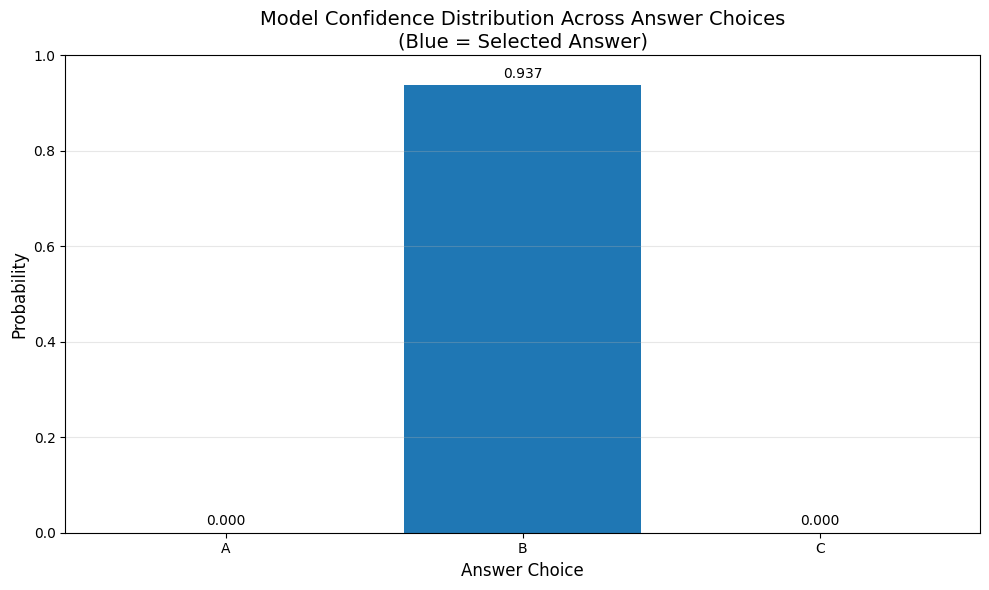


Predicted Answer: B
Confidence: 0.9371


In [43]:
# Extract probabilities for visualization
if answer_choices and len(answer_choices) > 0:
    choices = sorted(answer_choices.keys())
    probs = [answer_choices[c]['probability'] for c in choices]
    
    plt.figure(figsize=(10, 6))
    colors = ['#1f77b4' if c == result['generated_text'].strip() else '#7f7f7f' 
              for c in choices]
    
    plt.bar(choices, probs, color=colors)
    plt.xlabel('Answer Choice', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.title('Model Confidence Distribution Across Answer Choices\n(Blue = Selected Answer)', fontsize=14)
    
    # Set y-axis limit based on max probability
    if max(probs) > 0:
        plt.ylim([0, min(max(probs) * 1.2, 1.0)])
    
    # Add probability values on top of bars
    for i, (choice, prob) in enumerate(zip(choices, probs)):
        plt.text(i, prob + 0.01, f'{prob:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    predicted_answer = result['generated_text'].strip()
    if predicted_answer in answer_choices:
        print(f"\nPredicted Answer: {predicted_answer}")
        print(f"Confidence: {answer_choices[predicted_answer]['probability']:.4f}")
    else:
        print(f"\nPredicted Answer: {predicted_answer}")
        print(f"Warning: Predicted answer not found in answer_choices dictionary")
else:
    print("No answer choices found in the top logprobs!")
    print("This might indicate an issue with token extraction.")

## 5. Batch Processing Multiple Medical Questions

Process multiple MedQA-style questions and extract answer probabilities.

In [44]:
# Define multiple test questions
test_questions = [
    {
        "question": "A 35-year-old woman presents with weight loss, heat intolerance, and palpitations. Physical exam reveals exophthalmos and diffuse goiter. What is the most likely diagnosis?",
        "options": {
            "A": "Hashimoto's thyroiditis",
            "B": "Graves' disease",
            "C": "Toxic adenoma",
            "D": "Thyroid cancer"
        },
        "correct": "B"
    },
    {
        "question": "A 50-year-old diabetic patient presents with foot ulcer and fever. X-ray shows gas in soft tissues. What is the most appropriate immediate management?",
        "options": {
            "A": "Oral antibiotics and outpatient follow-up",
            "B": "Wound debridement and IV antibiotics",
            "C": "Topical antibiotics only",
            "D": "Observation and wound care"
        },
        "correct": "B"
    },
    {
        "question": "What is the first-line treatment for essential hypertension in a patient without comorbidities?",
        "options": {
            "A": "Beta blockers",
            "B": "ACE inhibitors or thiazide diuretics",
            "C": "Calcium channel blockers",
            "D": "Alpha blockers"
        },
        "correct": "B"
    }
]

def extract_answer_probs(prompt, model):
    """Extract answer choice probabilities from a prompt."""
    result = model.get_next_token_logits(prompt, return_full_distribution=True)
    
    answer_probs = {}
    if result['top_logprobs']:
        for alt in result['top_logprobs'][0]:
            token = alt['token']
            token_stripped = token.strip()
            
            # Check if it's a single letter answer choice
            if token_stripped in ['A', 'B', 'C', 'D', 'E']:
                prob = np.exp(alt['logprob'])
                
                # Keep the highest probability for each letter (in case both "A" and " A" appear)
                if token_stripped not in answer_probs or prob > answer_probs[token_stripped]:
                    answer_probs[token_stripped] = prob
    
    predicted = result['generated_text'].strip()
    confidence = answer_probs.get(predicted, 0.0)
    
    return {
        'predicted': predicted,
        'confidence': confidence,
        'all_probs': answer_probs
    }

# Process all questions
results_batch = []

for i, q in enumerate(test_questions):
    prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=2)
    result = extract_answer_probs(prompt, model_few_shot)
    
    results_batch.append({
        'question_num': i + 1,
        'predicted': result['predicted'],
        'correct': q['correct'],
        'confidence': result['confidence'],
        'is_correct': result['predicted'] == q['correct'],
        'all_probs': result['all_probs']
    })

# Print results
print("Batch Processing Results:")
print("="*80)
for r in results_batch:
    status = "✓" if r['is_correct'] else "✗"
    print(f"\nQuestion {r['question_num']}: {status}")
    print(f"  Predicted: {r['predicted']} (confidence: {r['confidence']:.4f})")
    print(f"  Correct: {r['correct']}")
    print(f"  All probabilities: {', '.join(f'{k}:{v:.4f}' for k, v in sorted(r['all_probs'].items()))}")

# Calculate accuracy
accuracy = sum(1 for r in results_batch if r['is_correct']) / len(results_batch)
avg_confidence = np.mean([r['confidence'] for r in results_batch])

print(f"\n" + "="*80)
print(f"Overall Accuracy: {accuracy:.2%}")
print(f"Average Confidence: {avg_confidence:.4f}")

Batch Processing Results:

Question 1: ✓
  Predicted: B (confidence: 0.9302)
  Correct: B
  All probabilities: A:0.0000, B:0.9302, D:0.0000

Question 2: ✓
  Predicted: B (confidence: 0.9603)
  Correct: B
  All probabilities: B:0.9603, C:0.0000, D:0.0000

Question 3: ✓
  Predicted: B (confidence: 0.8417)
  Correct: B
  All probabilities: A:0.0000, B:0.8417, C:0.0000, D:0.0000

Overall Accuracy: 100.00%
Average Confidence: 0.9107


## 6. Compare Zero-Shot vs Few-Shot Performance

Compare how few-shot examples affect the model's answer probability distribution.

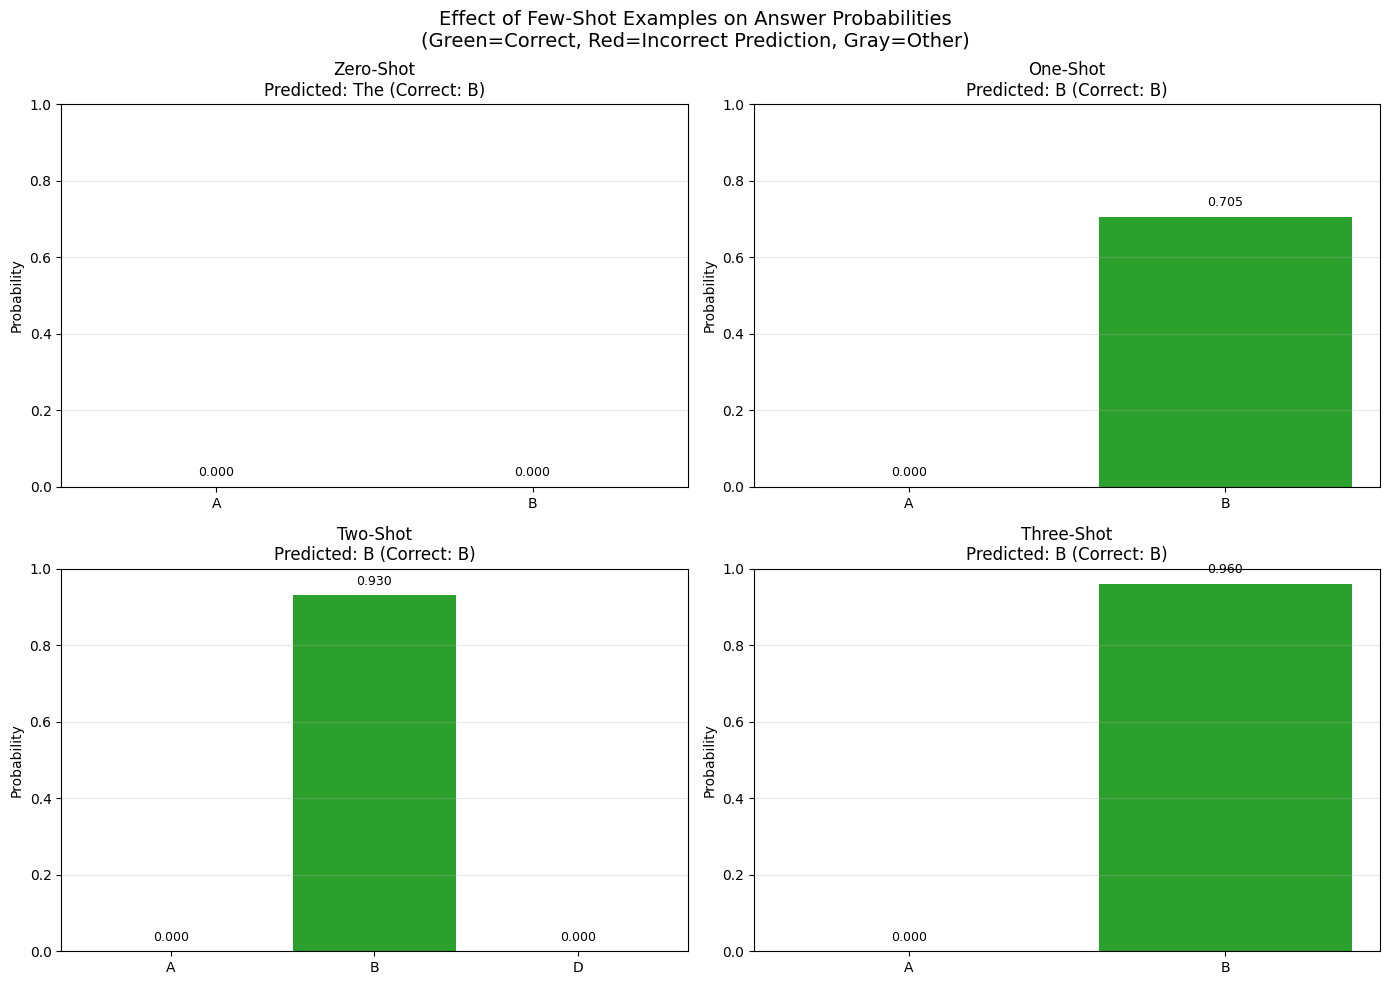


Question: A 35-year-old woman presents with weight loss, heat intolerance, and palpitations. Physical exam rev ...
Correct Answer: B

Confidence in predictions:
  Zero-Shot   : Predicted The with confidence 0.0000
  One-Shot    : Predicted B with confidence 0.7054
  Two-Shot    : Predicted B with confidence 0.9302
  Three-Shot  : Predicted B with confidence 0.9604


In [45]:
# Use the first test question
q = test_questions[0]

# Zero-shot prompt (no examples)
zero_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=0)

# Few-shot prompts with different numbers of examples
one_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=1)
two_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=2)
three_shot_prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=3)

# Extract probabilities for each
zero_shot_result = extract_answer_probs(zero_shot_prompt, model_few_shot)
one_shot_result = extract_answer_probs(one_shot_prompt, model_few_shot)
two_shot_result = extract_answer_probs(two_shot_prompt, model_few_shot)
three_shot_result = extract_answer_probs(three_shot_prompt, model_few_shot)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
results_list = [
    ('Zero-Shot', zero_shot_result),
    ('One-Shot', one_shot_result),
    ('Two-Shot', two_shot_result),
    ('Three-Shot', three_shot_result)
]

for idx, (title, result) in enumerate(results_list):
    ax = axes[idx // 2, idx % 2]
    
    choices = sorted(result['all_probs'].keys())
    probs = [result['all_probs'][c] for c in choices]
    
    colors = ['#2ca02c' if c == q['correct'] else '#d62728' if c == result['predicted'] and c != q['correct'] else '#7f7f7f' 
              for c in choices]
    
    ax.bar(choices, probs, color=colors)
    ax.set_ylabel('Probability')
    ax.set_title(f'{title}\nPredicted: {result["predicted"]} (Correct: {q["correct"]})')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add values on bars
    for i, (choice, prob) in enumerate(zip(choices, probs)):
        ax.text(i, prob + 0.02, f'{prob:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Effect of Few-Shot Examples on Answer Probabilities\n(Green=Correct, Red=Incorrect Prediction, Gray=Other)', 
             fontsize=14)
plt.tight_layout()
plt.show()

print("\nQuestion:", q['question'][:100], "...")
print(f"Correct Answer: {q['correct']}")
print("\nConfidence in predictions:")
for title, result in results_list:
    print(f"  {title:12s}: Predicted {result['predicted']} with confidence {result['confidence']:.4f}")

## 7. Uncertainty Analysis with Entropy

Calculate entropy of the answer probability distribution to measure model uncertainty.

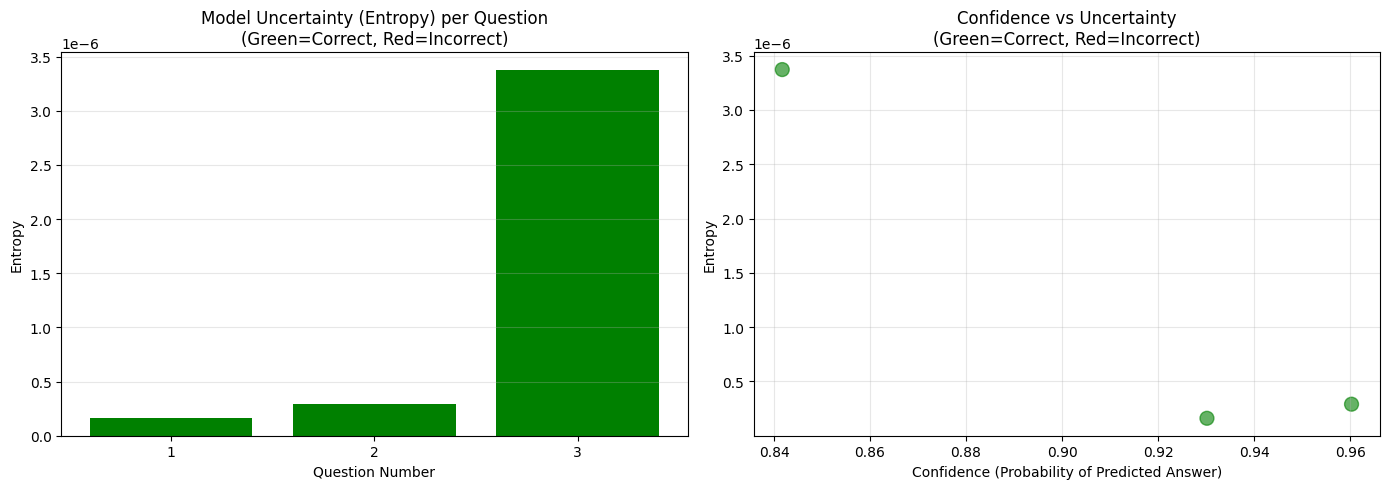

Entropy Analysis:
Question 1: ✓ | Entropy: 0.0000 | Confidence: 0.9302
Question 2: ✓ | Entropy: 0.0000 | Confidence: 0.9603
Question 3: ✓ | Entropy: 0.0000 | Confidence: 0.8417

Correlation between Confidence and Entropy: -0.9604
(Negative correlation expected: higher confidence → lower entropy)


In [46]:
def calculate_entropy(probs_dict):
    """Calculate entropy of probability distribution."""
    probs = np.array(list(probs_dict.values()))
    # Normalize to ensure sum = 1
    probs = probs / probs.sum()
    # Calculate entropy: -sum(p * log(p))
    entropy = -np.sum(probs * np.log(probs + 1e-10))
    return entropy

# Calculate entropy for all batch results
entropy_data = []

for i, (q, r) in enumerate(zip(test_questions, results_batch)):
    entropy = calculate_entropy(r['all_probs'])
    entropy_data.append({
        'question_num': i + 1,
        'entropy': entropy,
        'confidence': r['confidence'],
        'is_correct': r['is_correct']
    })

# Visualize entropy vs confidence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Entropy for each question
colors = ['green' if d['is_correct'] else 'red' for d in entropy_data]
ax1.bar(range(len(entropy_data)), [d['entropy'] for d in entropy_data], color=colors)
ax1.set_xlabel('Question Number')
ax1.set_ylabel('Entropy')
ax1.set_title('Model Uncertainty (Entropy) per Question\n(Green=Correct, Red=Incorrect)')
ax1.set_xticks(range(len(entropy_data)))
ax1.set_xticklabels([d['question_num'] for d in entropy_data])
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Scatter of Confidence vs Entropy
confidences = [d['confidence'] for d in entropy_data]
entropies = [d['entropy'] for d in entropy_data]
ax2.scatter(confidences, entropies, c=colors, s=100, alpha=0.6)
ax2.set_xlabel('Confidence (Probability of Predicted Answer)')
ax2.set_ylabel('Entropy')
ax2.set_title('Confidence vs Uncertainty\n(Green=Correct, Red=Incorrect)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Entropy Analysis:")
print("="*80)
for d in entropy_data:
    status = "✓" if d['is_correct'] else "✗"
    print(f"Question {d['question_num']}: {status} | Entropy: {d['entropy']:.4f} | Confidence: {d['confidence']:.4f}")

# Calculate correlation
correlation = np.corrcoef(confidences, entropies)[0, 1]
print(f"\nCorrelation between Confidence and Entropy: {correlation:.4f}")
print("(Negative correlation expected: higher confidence → lower entropy)")

## 8. Integration with MCal Framework

Format the output to be compatible with MCal calibration analysis.

In [47]:
def get_mcal_compatible_probabilities(questions_data, model, num_examples=2):
    """
    Get probabilities in MCal-compatible format.
    
    Returns:
        predictions: numpy array of shape (n_samples, n_classes) with probability distributions
        labels: numpy array of shape (n_samples,) with correct answer indices
    """
    predictions = []
    labels = []
    
    letter_to_idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
    
    for q in questions_data:
        # Create prompt
        prompt = create_few_shot_prompt(q['question'], q['options'], num_examples=num_examples)
        
        # Get probabilities
        result = extract_answer_probs(prompt, model)
        
        # Convert to array format [P(A), P(B), P(C), P(D), P(E)]
        num_options = len(q['options'])
        prob_array = np.zeros(num_options)
        
        for choice, prob in result['all_probs'].items():
            idx = letter_to_idx[choice]
            if idx < num_options:
                prob_array[idx] = prob
        
        # Normalize to ensure sum = 1
        if prob_array.sum() > 0:
            prob_array = prob_array / prob_array.sum()
        else:
            # Uniform distribution fallback
            prob_array = np.ones(num_options) / num_options
        
        predictions.append(prob_array)
        labels.append(letter_to_idx[q['correct']])
    
    return np.array(predictions), np.array(labels)

# Get MCal-compatible format
predictions, labels = get_mcal_compatible_probabilities(test_questions, model_few_shot, num_examples=2)

print("MCal-Compatible Output:")
print("="*80)
print(f"Predictions shape: {predictions.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nPredictions (probability distributions):")
print(predictions)
print(f"\nLabels (correct answer indices):")
print(labels)

# Calculate accuracy
predicted_labels = np.argmax(predictions, axis=1)
accuracy = np.mean(predicted_labels == labels)
print(f"\nAccuracy: {accuracy:.2%}")

# Calculate KL divergence (following medqa_kl_benchmark.py pattern)
def calculate_kl_divergence(predictions, device='cpu'):
    """
    Calculate KL divergence between predicted distribution and uniform distribution.
    Following the pattern from medqa_kl_benchmark.py
    """
    import torch
    import torch.nn.functional as F
    
    device = torch.device(device)
    n_samples, n_classes = predictions.shape
    
    # Convert to torch tensors
    preds_tensor = torch.tensor(predictions, dtype=torch.float32, device=device)
    
    # Calculate expectation distributions (from medqa_kl_benchmark.py get_expectation pattern)
    # Argmax expectation: one-hot encoding of most likely class
    predicted_classes = torch.argmax(preds_tensor, dim=1)
    one_hot_expectation = torch.zeros(n_classes, device=device)
    for c in range(n_classes):
        one_hot_expectation[c] = (predicted_classes == c).float().mean()
    
    # Probability expectation: average probability distribution
    prob_expectation = preds_tensor.mean(dim=0)
    
    # Reference distribution (uniform)
    uniform_dist = torch.ones(n_classes, device=device) / n_classes
    
    # Add small epsilon to avoid log(0)
    eps = 1e-10
    one_hot_expectation = one_hot_expectation + eps
    prob_expectation = prob_expectation + eps
    uniform_dist = uniform_dist + eps
    
    # Normalize
    one_hot_expectation = one_hot_expectation / one_hot_expectation.sum()
    prob_expectation = prob_expectation / prob_expectation.sum()
    uniform_dist = uniform_dist / uniform_dist.sum()
    
    # Calculate KL divergences: KL(expectation || uniform)
    kl_argmax = F.kl_div(uniform_dist.log(), one_hot_expectation, reduction='sum').item()
    kl_prob = F.kl_div(uniform_dist.log(), prob_expectation, reduction='sum').item()
    
    return kl_argmax, kl_prob, one_hot_expectation.cpu().numpy(), prob_expectation.cpu().numpy()

kl_argmax, kl_prob, argmax_dist, prob_dist = calculate_kl_divergence(predictions)

print(f"\n" + "="*80)
print(f"KL Divergence Metrics (following MCal framework):")
print(f"="*80)
print(f"KL Divergence (Argmax Expectation): {kl_argmax:.4f}")
print(f"KL Divergence (Probability Expectation): {kl_prob:.4f}")
print(f"\nArgmax Expectation Distribution: {argmax_dist}")
print(f"Probability Expectation Distribution: {prob_dist}")
print("\n(Lower KL divergence indicates predictions closer to uniform distribution)")
print("(This measures missingness bias - how much the model's predictions deviate from uniform)")

MCal-Compatible Output:
Predictions shape: (3, 4)
Labels shape: (3,)

Predictions (probability distributions):
[[4.36346235e-09 9.99999993e-01 2.64657370e-09 0.00000000e+00]
 [0.00000000e+00 9.99999990e-01 7.19413603e-09 2.99896207e-09]
 [1.27519074e-07 9.99999789e-01 7.73441543e-08 6.34879480e-09]]

Labels (correct answer indices):
[1 1 1]

Accuracy: 100.00%

KL Divergence Metrics (following MCal framework):
KL Divergence (Argmax Expectation): 1.3863
KL Divergence (Probability Expectation): 1.3863

Argmax Expectation Distribution: [1.e-10 1.e+00 1.e-10 1.e-10]
Probability Expectation Distribution: [4.4060840e-08 9.9999994e-01 2.9161622e-08 3.2159189e-09]

(Lower KL divergence indicates predictions closer to uniform distribution)
(This measures missingness bias - how much the model's predictions deviate from uniform)


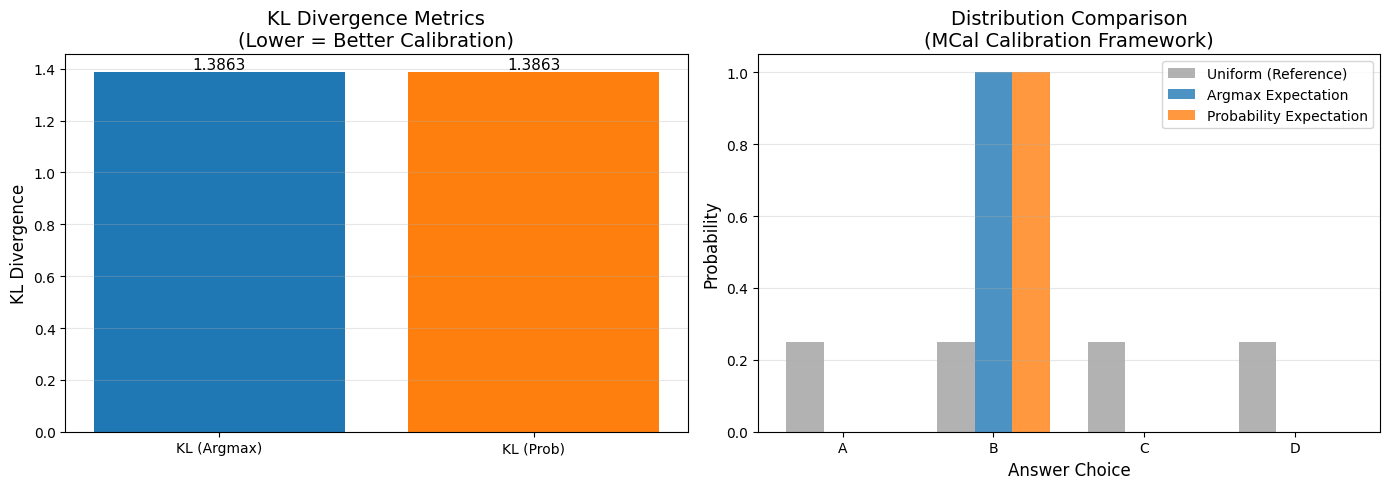


Interpretation:
KL Divergence measures how much the model's prediction distribution
deviates from a uniform distribution (missingness bias).

- Argmax Expectation: Based on the most likely predicted class
- Probability Expectation: Based on the average probability distribution

In the MCal framework:
  • Lower KL divergence = Better calibration / Less bias
  • Higher KL divergence = More bias towards certain classes


In [48]:
# Visualize KL Divergence and Distribution Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparing KL divergences
ax1 = axes[0]
kl_metrics = ['KL (Argmax)', 'KL (Prob)']
kl_values = [kl_argmax, kl_prob]
colors_kl = ['#1f77b4', '#ff7f0e']

bars = ax1.bar(kl_metrics, kl_values, color=colors_kl)
ax1.set_ylabel('KL Divergence', fontsize=12)
ax1.set_title('KL Divergence Metrics\n(Lower = Better Calibration)', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, val in zip(bars, kl_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=11)

# Plot 2: Distribution comparison
ax2 = axes[1]
x = np.arange(len(argmax_dist))
width = 0.25

# Uniform distribution
uniform = np.ones(len(argmax_dist)) / len(argmax_dist)

# Plot all three distributions
ax2.bar(x - width, uniform, width, label='Uniform (Reference)', color='gray', alpha=0.6)
ax2.bar(x, argmax_dist, width, label='Argmax Expectation', color='#1f77b4', alpha=0.8)
ax2.bar(x + width, prob_dist, width, label='Probability Expectation', color='#ff7f0e', alpha=0.8)

ax2.set_xlabel('Answer Choice', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Distribution Comparison\n(MCal Calibration Framework)', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(['A', 'B', 'C', 'D'][:len(argmax_dist)])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("="*80)
print("KL Divergence measures how much the model's prediction distribution")
print("deviates from a uniform distribution (missingness bias).")
print("\n- Argmax Expectation: Based on the most likely predicted class")
print("- Probability Expectation: Based on the average probability distribution")
print("\nIn the MCal framework:")
print("  • Lower KL divergence = Better calibration / Less bias")
print("  • Higher KL divergence = More bias towards certain classes")

## 8A. Visualize KL Divergence and Distribution Comparison

## 8B. LIME Feature Importance Analysis

Use LIME (Local Interpretable Model-agnostic Explanations) to understand which words in a medical question are most important for the model's prediction.

In [ ]:
# LIME Implementation for OpenAI API Models
# Adapted to work with API-based models and consistent with MCal's perturbation strategy

class TextLIME_OpenAI:
    """
    LIME for text classification using OpenAI API models.
    Compatible with the MCal framework's perturbation strategy.
    """
    
    def __init__(self, model, num_samples=100):
        """
        Initialize TextLIME for OpenAI models.
        
        Args:
            model: OpenAIModel instance
            num_samples: Number of perturbed samples to generate
        """
        self.model = model
        self.num_samples = num_samples
    
    def perturb_text(self, words, removal_fraction=None):
        """
        Create a perturbed version of text by removing words.
        Compatible with MCal's replace_random_features strategy.
        
        Args:
            words: List of words
            removal_fraction: Fraction of words to remove (if None, random binary mask)
        
        Returns:
            Perturbed text, binary mask indicating kept words
        """
        n_words = len(words)
        
        if removal_fraction is not None:
            # Use specific removal fraction
            num_remove = int(n_words * removal_fraction)
            indices_to_remove = np.random.choice(n_words, size=num_remove, replace=False)
            binary_mask = np.ones(n_words)
            binary_mask[indices_to_remove] = 0
        else:
            # Random binary mask (LIME standard)
            binary_mask = np.random.randint(0, 2, size=n_words)
            
            # Ensure at least one word is kept
            if binary_mask.sum() == 0:
                binary_mask[np.random.randint(0, n_words)] = 1
        
        # Create perturbed text (keep only words where mask=1)
        perturbed_words = [word for i, word in enumerate(words) if binary_mask[i] == 1]
        perturbed_text = ' '.join(perturbed_words)
        
        return perturbed_text, binary_mask
    
    def get_prediction_for_text(self, question_text, options, num_examples=2):
        """
        Get model prediction probability for a specific class.
        
        Args:
            question_text: The question text (potentially perturbed)
            options: Answer options dictionary
            num_examples: Number of few-shot examples
        
        Returns:
            Dictionary with probabilities for each answer choice
        """
        prompt = create_few_shot_prompt(question_text, options, num_examples=num_examples)
        result = extract_answer_probs(prompt, self.model)
        return result['all_probs']
    
    def explain_instance(self, question_text, options, target_class, num_examples=2):
        """
        Generate LIME explanation for a text instance.
        
        Args:
            question_text: The question text to explain
            options: Answer options dictionary
            target_class: The class to explain (e.g., 'B')
            num_examples: Number of few-shot examples
        
        Returns:
            importance_scores: Importance score for each word
            words: List of words in the original text
        """
        # Tokenize text into words
        words = question_text.split()
        n_words = len(words)
        
        # Generate perturbed samples
        perturbed_samples = []
        binary_masks = []
        predictions = []
        
        print(f"Generating {self.num_samples} perturbed samples...")
        
        for i in range(self.num_samples):
            perturbed_text, binary_mask = self.perturb_text(words)
            perturbed_samples.append(perturbed_text)
            binary_masks.append(binary_mask)
            
            # Get prediction for perturbed text
            probs = self.get_prediction_for_text(perturbed_text, options, num_examples)
            
            # Extract probability for target class
            target_prob = probs.get(target_class, 0.0)
            predictions.append(target_prob)
        
        # Convert to numpy arrays
        binary_masks = np.array(binary_masks)  # Shape: (num_samples, n_words)
        predictions = np.array(predictions)    # Shape: (num_samples,)
        
        print(f"Fitting linear model to explain predictions...")
        
        # Fit linear model using ridge regression
        # y = predictions, X = binary_masks (which words are present)
        
        # Weight samples by similarity (number of words kept)
        weights = binary_masks.sum(axis=1) / n_words
        
        # Add bias term
        X = np.column_stack([binary_masks, np.ones(self.num_samples)])
        
        # Weighted least squares
        W = np.diag(weights)
        XtWX = X.T @ W @ X
        XtWy = X.T @ W @ predictions
        
        # Ridge regularization
        alpha = 1.0
        XtWX = XtWX + alpha * np.eye(XtWX.shape[0])
        
        # Solve for coefficients
        coef = np.linalg.solve(XtWX, XtWy)
        
        # Get feature importances (exclude bias term)
        importance_scores = coef[:-1]
        
        return importance_scores, words

# Test with a short medical question
lime_test_question = {
    "question": "What vitamin deficiency causes night blindness?",
    "options": {
        "A": "Vitamin A",
        "B": "Vitamin B12", 
        "C": "Vitamin C",
        "D": "Vitamin D"
    },
    "correct": "A"
}

print("LIME Test Question:")
print("="*80)
print(f"Question: {lime_test_question['question']}")
print(f"Correct Answer: {lime_test_question['correct']}")
print("="*80)

In [ ]:
# Get model's original prediction
original_prompt = create_few_shot_prompt(
    lime_test_question['question'],
    lime_test_question['options'],
    num_examples=2
)
original_result = extract_answer_probs(original_prompt, model_few_shot)

predicted_class = original_result['predicted']
confidence = original_result['confidence']

print(f"\nOriginal Model Prediction:")
print(f"  Predicted: {predicted_class}")
print(f"  Confidence: {confidence:.4f}")
print(f"  All probabilities: {original_result['all_probs']}")

# Initialize LIME explainer
lime_explainer = TextLIME_OpenAI(model=model_few_shot, num_samples=100)

# Generate explanation for the predicted class
print(f"\nGenerating LIME explanation for predicted class '{predicted_class}'...")
print("(This will make ~100 API calls and may take 1-2 minutes)")
print("="*80)

importance_scores, words = lime_explainer.explain_instance(
    question_text=lime_test_question['question'],
    options=lime_test_question['options'],
    target_class=predicted_class,
    num_examples=2
)

print("\nLIME Explanation Complete!")
print("="*80)
print("\nWord Importance Scores:")
print("-"*80)
for word, score in zip(words, importance_scores):
    print(f"  {word:20s} : {score:+.6f}")
print("="*80)
print("\nInterpretation:")
print("  • Positive scores: Words that increase confidence in the prediction")
print("  • Negative scores: Words that decrease confidence in the prediction")
print("  • Magnitude: How important the word is (larger absolute value = more important)")

In [ ]:
# Visualization 1: Bar chart of word importances

# Sort words by importance score
sorted_indices = np.argsort(np.abs(importance_scores))[::-1]
sorted_words = [words[i] for i in sorted_indices]
sorted_scores = importance_scores[sorted_indices]

# Create bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart (all words)
ax1 = axes[0]
colors = ['#2ca02c' if score > 0 else '#d62728' for score in sorted_scores]
bars = ax1.barh(range(len(sorted_words)), sorted_scores, color=colors, alpha=0.7)
ax1.set_yticks(range(len(sorted_words)))
ax1.set_yticklabels(sorted_words, fontsize=10)
ax1.set_xlabel('LIME Importance Score', fontsize=12)
ax1.set_title(f'Word Importance for Predicting "{predicted_class}"\n(Green=Positive, Red=Negative)', 
              fontsize=13, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Add value labels
for i, (bar, score) in enumerate(zip(bars, sorted_scores)):
    width = bar.get_width()
    label_x_pos = width + (0.01 if width > 0 else -0.01)
    ax1.text(label_x_pos, i, f'{score:.4f}',
            ha='left' if width > 0 else 'right', va='center', fontsize=8)

# Plot 2: Top 5 most important words (by absolute value)
ax2 = axes[1]
top_5_indices = sorted_indices[:5]
top_5_words = [words[i] for i in top_5_indices]
top_5_scores = importance_scores[top_5_indices]
colors_top5 = ['#2ca02c' if score > 0 else '#d62728' for score in top_5_scores]

bars2 = ax2.barh(range(len(top_5_words)), top_5_scores, color=colors_top5, alpha=0.7)
ax2.set_yticks(range(len(top_5_words)))
ax2.set_yticklabels(top_5_words, fontsize=11)
ax2.set_xlabel('LIME Importance Score', fontsize=12)
ax2.set_title(f'Top 5 Most Important Words\nfor Predicting "{predicted_class}"', 
              fontsize=13, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Add value labels
for i, (bar, score) in enumerate(zip(bars2, top_5_scores)):
    width = bar.get_width()
    label_x_pos = width + (0.01 if width > 0 else -0.01)
    ax2.text(label_x_pos, i, f'{score:.4f}',
            ha='left' if width > 0 else 'right', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Visualization 2: Color-coded text highlighting

from matplotlib import colors as mcolors
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable

def normalize_scores_for_color(scores, vmin=None, vmax=None):
    """Normalize scores to [-1, 1] range for color mapping."""
    if vmin is None:
        vmin = scores.min()
    if vmax is None:
        vmax = scores.max()
    
    # Handle case where all scores are the same
    if vmax == vmin:
        return np.zeros_like(scores)
    
    # Normalize to [-1, 1] with symmetric scaling
    abs_max = max(abs(vmin), abs(vmax))
    if abs_max > 0:
        normalized = scores / abs_max
    else:
        normalized = scores
    
    return normalized

# Normalize importance scores for visualization
normalized_scores = normalize_scores_for_color(importance_scores)

# Create figure for color-coded text
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

# Title
fig.suptitle(f'LIME Explanation: Color-Coded Word Importance for "{predicted_class}"', 
             fontsize=14, fontweight='bold', y=0.85)

# Color map: green for positive, red for negative
cmap_green_red = mcolors.LinearSegmentedColormap.from_list(
    'green_red', ['#d62728', '#ffffff', '#2ca02c']
)

# Display words with background colors
x_position = 0.05
y_position = 0.5
word_spacing = 0.01

for word, score, norm_score in zip(words, importance_scores, normalized_scores):
    # Get color based on normalized score
    color = cmap_green_red((norm_score + 1) / 2)  # Map [-1,1] to [0,1]
    
    # Add text with colored background
    text = ax.text(x_position, y_position, f' {word} ', 
                   fontsize=13, 
                   bbox=dict(boxstyle='round,pad=0.3', 
                            facecolor=color, 
                            edgecolor='gray', 
                            linewidth=0.5,
                            alpha=0.8),
                   verticalalignment='center')
    
    # Get text width to position next word
    text_bbox = text.get_window_extent(renderer=fig.canvas.get_renderer())
    text_width = text_bbox.width / fig.dpi / fig.get_size_inches()[0]
    
    x_position += text_width + word_spacing
    
    # Wrap to next line if needed
    if x_position > 0.95:
        x_position = 0.05
        y_position -= 0.15

# Add color bar legend
cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.05])
norm = mcolors.Normalize(vmin=-1, vmax=1)
cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap_green_red),
                  cax=cbar_ax, orientation='horizontal')
cb.set_label('Normalized LIME Importance Score', fontsize=11)
cb.set_ticks([-1, -0.5, 0, 0.5, 1])
cb.set_ticklabels(['Strong\nNegative', 'Negative', 'Neutral', 'Positive', 'Strong\nPositive'])

plt.tight_layout()
plt.show()

print("\nColor-coded Interpretation:")
print("="*80)
print("• Green background: Words that increase confidence in the prediction")
print("• Red background: Words that decrease confidence in the prediction")  
print("• White/Gray background: Neutral words with little impact")
print("• Intensity: Stronger color = more important word")
print("="*80)

In [ ]:
# Summary of LIME Analysis

print("\n" + "="*80)
print("LIME Analysis Summary")
print("="*80)
print(f"\nQuestion: '{lime_test_question['question']}'")
print(f"Model Prediction: {predicted_class} (confidence: {confidence:.4f})")
print(f"Correct Answer: {lime_test_question['correct']}")
print(f"Prediction is: {'CORRECT' if predicted_class == lime_test_question['correct'] else 'INCORRECT'}")

print("\n" + "-"*80)
print("Key Insights from LIME:")
print("-"*80)

# Find most important words
top_positive_idx = np.argmax(importance_scores)
top_negative_idx = np.argmin(importance_scores)
top_absolute_idx = np.argmax(np.abs(importance_scores))

print(f"\n1. Most Positive Word (increases confidence):")
print(f"   '{words[top_positive_idx]}' with score {importance_scores[top_positive_idx]:+.6f}")

print(f"\n2. Most Negative Word (decreases confidence):")
print(f"   '{words[top_negative_idx]}' with score {importance_scores[top_negative_idx]:+.6f}")

print(f"\n3. Most Important Word (by absolute value):")
print(f"   '{words[top_absolute_idx]}' with score {importance_scores[top_absolute_idx]:+.6f}")

# Top 3 by absolute importance
top_3_abs = sorted_indices[:3]
print(f"\n4. Top 3 Most Important Words:")
for i, idx in enumerate(top_3_abs, 1):
    print(f"   {i}. '{words[idx]}' (score: {importance_scores[idx]:+.6f})")

print("\n" + "="*80)
print("Connection to MCal Framework:")
print("="*80)
print("• LIME identifies which words are most important for the prediction")
print("• This can guide INTELLIGENT feature ablation (vs random removal)")
print("• Future work: Compare LIME-guided ablation vs random ablation in MCal")
print("• Hypothesis: Removing important words should cause larger distribution shifts")
print("="*80)

## 9. Full MCal Pipeline: Feature Perturbation + Calibration

Demonstrate the complete MCal workflow:
1. Load a larger batch of medical questions
2. Perturb features (simulate missing information) 
3. Calculate baseline KL divergence
4. Apply MCal_CE calibration
5. Compare calibrated vs uncalibrated KL divergence

**Note:** Please run the cells in this section in sequential order (top to bottom) for proper execution.

In [49]:
# Import required modules for MCal
import sys
sys.path.insert(0, '../src')
sys.path.insert(0, '../experiments/language')

from src.calibrators.mcal_ce import MCal_CE
import torch
import torch.nn.functional as F

# Feature perturbation utility (from medqa_utils.py)
def replace_random_features(text, removal_fraction=0.15, replacement_token='UNKWORDZ'):
    """Replace random words/tokens with a replacement token."""
    tokens = text.split()
    num_replace = int(len(tokens) * removal_fraction)
    
    if num_replace > 0 and len(tokens) > 0:
        import random
        indices_to_replace = random.sample(range(len(tokens)), min(num_replace, len(tokens)))
    else:
        indices_to_replace = []
    
    modified_tokens = [replacement_token if i in indices_to_replace else token for i, token in enumerate(tokens)]
    modified_text = ' '.join(modified_tokens)
    
    return modified_text

# Configuration
N_QUESTIONS = 20  # Larger batch for demonstration
N_FRACTIONS = 10  # Number of perturbation levels
REMOVAL_FRACTIONS = np.linspace(0, 0.9, N_FRACTIONS)  # 0% to 90% removal

print("="*80)
print("MCal Pipeline Demo: Feature Perturbation + Calibration")
print("="*80)
print(f"Number of questions: {N_QUESTIONS}")
print(f"Perturbation fractions: {REMOVAL_FRACTIONS}")
print(f"Number of perturbation levels: {N_FRACTIONS}")
print("="*80)

MCal Pipeline Demo: Feature Perturbation + Calibration
Number of questions: 20
Perturbation fractions: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
Number of perturbation levels: 10


In [50]:
# Step 1: Load larger batch of medical questions
# We'll create a more diverse set of medical MCQs for demonstration

medical_questions_large = [
    {
        "question": "A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. What is the most likely diagnosis?",
        "options": {"A": "Viral pneumonia", "B": "Bacterial pneumonia", "C": "Tuberculosis", "D": "Lung cancer"},
        "correct": "B"
    },
    {
        "question": "A 35-year-old woman presents with weight loss, heat intolerance, and palpitations. Physical exam reveals exophthalmos and diffuse goiter. What is the most likely diagnosis?",
        "options": {"A": "Hashimoto's thyroiditis", "B": "Graves' disease", "C": "Toxic adenoma", "D": "Thyroid cancer"},
        "correct": "B"
    },
    {
        "question": "Which hormone is primarily responsible for regulating blood glucose levels?",
        "options": {"A": "Cortisol", "B": "Insulin", "C": "Thyroxine", "D": "Glucagon"},
        "correct": "B"
    },
    {
        "question": "A 65-year-old patient presents with chest pain radiating to the left arm and diaphoresis. ECG shows ST-segment elevation in leads II, III, and aVF. What is the most likely diagnosis?",
        "options": {"A": "GERD", "B": "Inferior wall MI", "C": "Costochondritis", "D": "Pulmonary embolism"},
        "correct": "B"
    },
    {
        "question": "What is the first-line treatment for essential hypertension in a patient without comorbidities?",
        "options": {"A": "Beta blockers", "B": "ACE inhibitors or thiazide diuretics", "C": "Calcium channel blockers", "D": "Alpha blockers"},
        "correct": "B"
    },
    {
        "question": "A 50-year-old diabetic patient presents with foot ulcer and fever. X-ray shows gas in soft tissues. What is the most appropriate immediate management?",
        "options": {"A": "Oral antibiotics and outpatient follow-up", "B": "Wound debridement and IV antibiotics", "C": "Topical antibiotics only", "D": "Observation and wound care"},
        "correct": "B"
    },
    {
        "question": "A 30-year-old woman presents with sudden onset severe headache described as 'worst headache of my life'. What is the most likely diagnosis?",
        "options": {"A": "Migraine", "B": "Subarachnoid hemorrhage", "C": "Tension headache", "D": "Cluster headache"},
        "correct": "B"
    },
    {
        "question": "What is the most common cause of hyperthyroidism?",
        "options": {"A": "Hashimoto's thyroiditis", "B": "Graves' disease", "C": "Toxic multinodular goiter", "D": "Thyroid adenoma"},
        "correct": "B"
    },
    {
        "question": "A patient with chronic kidney disease presents with bone pain and elevated alkaline phosphatase. What is the most likely diagnosis?",
        "options": {"A": "Osteoporosis", "B": "Renal osteodystrophy", "C": "Multiple myeloma", "D": "Paget's disease"},
        "correct": "B"
    },
    {
        "question": "Which vitamin deficiency is associated with night blindness?",
        "options": {"A": "Vitamin A", "B": "Vitamin B12", "C": "Vitamin C", "D": "Vitamin D"},
        "correct": "A"
    },
    {
        "question": "A 55-year-old man with a history of smoking presents with hemoptysis and weight loss. Chest X-ray shows a hilar mass. What is the most likely diagnosis?",
        "options": {"A": "Tuberculosis", "B": "Lung cancer", "C": "Pneumonia", "D": "Sarcoidosis"},
        "correct": "B"
    },
    {
        "question": "What is the mechanism of action of aspirin?",
        "options": {"A": "Irreversibly inhibits COX-1 and COX-2", "B": "Reversibly inhibits COX-1 and COX-2", "C": "Blocks thromboxane receptors", "D": "Inhibits phosphodiesterase"},
        "correct": "A"
    },
    {
        "question": "A newborn presents with bilious vomiting within the first 24 hours of life. What is the most concerning diagnosis?",
        "options": {"A": "Pyloric stenosis", "B": "Intestinal malrotation with volvulus", "C": "Gastroesophageal reflux", "D": "Feeding intolerance"},
        "correct": "B"
    },
    {
        "question": "Which of the following is a contraindication for thrombolytic therapy in acute MI?",
        "options": {"A": "History of ischemic stroke within 3 months", "B": "Age over 75", "C": "Diabetes mellitus", "D": "Hypertension"},
        "correct": "A"
    },
    {
        "question": "A patient presents with jaundice, right upper quadrant pain, and fever (Charcot's triad). What is the most likely diagnosis?",
        "options": {"A": "Acute cholecystitis", "B": "Ascending cholangitis", "C": "Hepatitis", "D": "Pancreatitis"},
        "correct": "B"
    },
    {
        "question": "What is the gold standard test for diagnosing celiac disease?",
        "options": {"A": "Small bowel biopsy showing villous atrophy", "B": "Anti-tissue transglutaminase antibody", "C": "HLA-DQ2/DQ8 testing", "D": "Stool fat test"},
        "correct": "A"
    },
    {
        "question": "A 70-year-old man presents with difficulty urinating and elevated PSA. Digital rectal exam reveals enlarged, firm prostate. What is the next best step?",
        "options": {"A": "Transrectal ultrasound-guided biopsy", "B": "Start finasteride", "C": "CT abdomen and pelvis", "D": "Repeat PSA in 6 months"},
        "correct": "A"
    },
    {
        "question": "Which immunoglobulin crosses the placenta?",
        "options": {"A": "IgG", "B": "IgM", "C": "IgA", "D": "IgE"},
        "correct": "A"
    },
    {
        "question": "A patient with known atrial fibrillation presents with sudden onset of right leg pain and pallor. What is the most likely diagnosis?",
        "options": {"A": "Acute arterial embolism", "B": "Deep vein thrombosis", "C": "Compartment syndrome", "D": "Cellulitis"},
        "correct": "A"
    },
    {
        "question": "What is the most common cause of acute pancreatitis in developed countries?",
        "options": {"A": "Gallstones", "B": "Alcohol", "C": "Hypertriglyceridemia", "D": "Medications"},
        "correct": "A"
    }
]

# Trim to N_QUESTIONS
medical_questions_large = medical_questions_large[:N_QUESTIONS]

print(f"\nLoaded {len(medical_questions_large)} medical questions")
print("\nSample question:")
print(f"Q: {medical_questions_large[0]['question'][:100]}...")
print(f"Correct answer: {medical_questions_large[0]['correct']}")


Loaded 20 medical questions

Sample question:
Q: A 45-year-old man presents with fever and productive cough. Chest X-ray shows lobar consolidation. W...
Correct answer: B


In [51]:
# Step 2: Generate predictions with feature perturbation
# For each perturbation level, we'll:
# 1. Perturb the question text
# 2. Get model predictions
# 3. Store predictions in shape (n_fractions, n_samples, n_classes)

print("\n" + "="*80)
print("Step 2: Generating predictions with feature perturbation")
print("="*80)

# Initialize model with lower temperature for more stable predictions
model_pipeline = OpenAIModel(
    model_name="gpt-4o-mini",
    top_logprobs=20,
    temperature=0.5,  # Moderate temperature
    max_tokens=1
)

# Storage for all predictions
all_predictions = np.zeros((N_FRACTIONS, N_QUESTIONS, 4))  # 4 answer choices (A, B, C, D)
letter_to_idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

# Generate predictions for each perturbation level
for frac_idx, removal_frac in enumerate(REMOVAL_FRACTIONS):
    print(f"\nProcessing perturbation level {frac_idx+1}/{N_FRACTIONS} (removal={removal_frac:.2f})...")
    
    for q_idx, question_data in enumerate(medical_questions_large):
        # Perturb the question text
        if removal_frac > 0:
            perturbed_question = replace_random_features(
                question_data['question'], 
                removal_fraction=removal_frac
            )
        else:
            perturbed_question = question_data['question']
        
        # Create prompt with perturbed question
        prompt = create_few_shot_prompt(
            perturbed_question, 
            question_data['options'], 
            num_examples=2
        )
        
        # Get predictions
        result = model_pipeline.get_next_token_logits(prompt, return_full_distribution=True)
        
        # Extract answer probabilities
        answer_probs = {}
        if result['top_logprobs']:
            for alt in result['top_logprobs'][0]:
                token_stripped = alt['token'].strip()
                if token_stripped in ['A', 'B', 'C', 'D']:
                    prob = np.exp(alt['logprob'])
                    if token_stripped not in answer_probs or prob > answer_probs[token_stripped]:
                        answer_probs[token_stripped] = prob
        
        # Store probabilities (fill with zeros if not found)
        for choice in ['A', 'B', 'C', 'D']:
            idx = letter_to_idx[choice]
            all_predictions[frac_idx, q_idx, idx] = answer_probs.get(choice, 0.0)
        
        # Normalize
        prob_sum = all_predictions[frac_idx, q_idx, :].sum()
        if prob_sum > 0:
            all_predictions[frac_idx, q_idx, :] /= prob_sum
        else:
            # Uniform fallback
            all_predictions[frac_idx, q_idx, :] = 0.25
    
    print(f"  Completed {N_QUESTIONS} questions")

# Extract labels
labels = np.array([letter_to_idx[q['correct']] for q in medical_questions_large])

print(f"\nPredictions shape: {all_predictions.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nSample prediction (fraction 0, question 0): {all_predictions[0, 0, :]}")
print(f"Sum: {all_predictions[0, 0, :].sum():.4f}")


Step 2: Generating predictions with feature perturbation

Processing perturbation level 1/10 (removal=0.00)...
  Completed 20 questions

Processing perturbation level 2/10 (removal=0.10)...
  Completed 20 questions

Processing perturbation level 3/10 (removal=0.20)...
  Completed 20 questions

Processing perturbation level 4/10 (removal=0.30)...
  Completed 20 questions

Processing perturbation level 5/10 (removal=0.40)...
  Completed 20 questions

Processing perturbation level 6/10 (removal=0.50)...
  Completed 20 questions

Processing perturbation level 7/10 (removal=0.60)...
  Completed 20 questions

Processing perturbation level 8/10 (removal=0.70)...
  Completed 20 questions

Processing perturbation level 9/10 (removal=0.80)...
  Completed 20 questions

Processing perturbation level 10/10 (removal=0.90)...
  Completed 20 questions

Predictions shape: (10, 20, 4)
Labels shape: (20,)

Sample prediction (fraction 0, question 0): [0. 1. 0. 0.]
Sum: 1.0000


In [52]:
# Step 3: Calculate baseline KL divergence (following medqa_kl_benchmark.py pattern)

def calculate_kl_metrics_fractionwise(predictions_array, labels_array, device='cpu'):
    """
    Calculate KL divergence for each fraction level.
    Following the pattern from medqa_kl_benchmark.py calculate_kl_metrics()
    
    Args:
        predictions_array: numpy array of shape (n_fractions, n_samples, n_classes)
        labels_array: numpy array of shape (n_samples,)
        device: device to use for computation
    
    Returns:
        Dictionary with KL metrics and accuracy for each fraction
    """
    device = torch.device(device)
    n_fractions, n_samples, n_classes = predictions_array.shape
    
    # Use clean predictions (fraction 0) as reference
    clean_dist = torch.tensor(predictions_array[0], dtype=torch.float32, device=device).mean(dim=0)
    
    results = {
        'kl_argmax': [],
        'kl_prob': [],
        'accuracy': []
    }
    
    for frac_idx in range(n_fractions):
        # Get predictions for this fraction
        frac_preds = torch.tensor(predictions_array[frac_idx], dtype=torch.float32, device=device)
        
        # Calculate expectations (from src/utils/optimization.py get_expectation pattern)
        # Argmax expectation
        predicted_classes = torch.argmax(frac_preds, dim=1)
        one_hot_expectation = torch.zeros(n_classes, device=device)
        for c in range(n_classes):
            one_hot_expectation[c] = (predicted_classes == c).float().mean()
        
        # Probability expectation
        prob_expectation = frac_preds.mean(dim=0)
        
        # Add epsilon and normalize
        eps = 1e-10
        one_hot_expectation = one_hot_expectation + eps
        prob_expectation = prob_expectation + eps
        clean_dist_normalized = clean_dist + eps
        
        one_hot_expectation = one_hot_expectation / one_hot_expectation.sum()
        prob_expectation = prob_expectation / prob_expectation.sum()
        clean_dist_normalized = clean_dist_normalized / clean_dist_normalized.sum()
        
        # Calculate KL divergences: KL(expectation || clean)
        kl_argmax = F.kl_div(clean_dist_normalized.log(), one_hot_expectation, reduction='sum').item()
        kl_prob = F.kl_div(clean_dist_normalized.log(), prob_expectation, reduction='sum').item()
        
        # Calculate accuracy
        predicted_labels = np.argmax(predictions_array[frac_idx], axis=1)
        accuracy = float(np.mean(predicted_labels == labels_array))
        
        results['kl_argmax'].append(kl_argmax)
        results['kl_prob'].append(kl_prob)
        results['accuracy'].append(accuracy)
    
    return results

# Calculate baseline KL divergence
print("\n" + "="*80)
print("Step 3: Calculating baseline KL divergence")
print("="*80)

baseline_results = calculate_kl_metrics_fractionwise(all_predictions, labels)

print("\nBaseline Results (Uncalibrated):")
print("-" * 80)
print(f"{'Fraction':<15} {'Removal %':<15} {'KL (Argmax)':<15} {'KL (Prob)':<15} {'Accuracy':<15}")
print("-" * 80)
for i, removal_frac in enumerate(REMOVAL_FRACTIONS):
    print(f"{i:<15} {removal_frac*100:<15.1f} {baseline_results['kl_argmax'][i]:<15.6f} "
          f"{baseline_results['kl_prob'][i]:<15.6f} {baseline_results['accuracy'][i]:<15.4f}")

avg_kl_argmax_baseline = np.mean(baseline_results['kl_argmax'])
avg_kl_prob_baseline = np.mean(baseline_results['kl_prob'])
avg_accuracy_baseline = np.mean(baseline_results['accuracy'])

print("-" * 80)
print(f"{'Average':<15} {'':<15} {avg_kl_argmax_baseline:<15.6f} "
      f"{avg_kl_prob_baseline:<15.6f} {avg_accuracy_baseline:<15.4f}")
print("="*80)


Step 3: Calculating baseline KL divergence

Baseline Results (Uncalibrated):
--------------------------------------------------------------------------------
Fraction        Removal %       KL (Argmax)     KL (Prob)       Accuracy       
--------------------------------------------------------------------------------
0               0.0             0.000007        0.000000        1.0000         
1               10.0            0.004910        0.003909        0.9500         
2               20.0            0.004910        0.122454        0.9500         
3               30.0            0.908742        0.905674        0.8500         
4               40.0            0.678689        0.633867        0.9000         
5               50.0            0.666619        0.562266        0.9000         
6               60.0            0.004910        0.369144        0.8500         
7               70.0            1.464515        1.824275        0.7500         
8               80.0            3.099155

In [53]:
# Step 4: Apply MCal_CE calibration
# Following the pattern from medqa_kl_benchmark.py apply_mcal_ce_calibrator()

print("\n" + "="*80)
print("Step 4: Applying MCal_CE calibration")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert to torch tensors
all_predictions_tensor = torch.tensor(all_predictions, dtype=torch.float32, device=device)
labels_tensor = torch.tensor(labels, dtype=torch.long, device=device)

# Use fraction 0 predictions as target labels (following MCal pattern)
target_labels = all_predictions_tensor[0].argmax(dim=-1)

n_fractions, n_samples, n_classes = all_predictions_tensor.shape
calibrated_predictions = np.zeros_like(all_predictions)

print(f"\nTraining MCal_CE calibrator for each perturbation level...")
print(f"Number of fractions: {n_fractions}")
print(f"Number of samples: {n_samples}")
print(f"Number of classes: {n_classes}")

# Train and apply MCal_CE for each fraction
for frac_idx in range(n_fractions):
    print(f"\n--- Fraction {frac_idx}/{n_fractions-1} (removal={REMOVAL_FRACTIONS[frac_idx]:.2f}) ---")
    
    # Create MCal_CE calibrator
    calibrator = MCal_CE(num_classes=n_classes, head_type="linear")
    calibrator.to(device)
    
    # Train calibrator
    calibrator.fit(
        ablated_probs=all_predictions_tensor[frac_idx],
        target_labels=target_labels,
        max_steps=1000,  # Fewer steps for demo
        lr=1e-2,
        verbose=False,  # Set to True to see training progress
        fraction=frac_idx,
        experiment_id="openai_demo"
    )
    
    # Apply calibration
    with torch.no_grad():
        calibrated_probs = calibrator.forward(all_predictions_tensor[frac_idx])
        calibrated_predictions[frac_idx] = calibrated_probs.cpu().numpy()
    
    print(f"  Calibration complete for fraction {frac_idx}")

print("\n" + "="*80)
print("MCal_CE calibration completed for all fractions")
print("="*80)


Step 4: Applying MCal_CE calibration
Using device: cuda

Training MCal_CE calibrator for each perturbation level...
Number of fractions: 10
Number of samples: 20
Number of classes: 4

--- Fraction 0/9 (removal=0.00) ---
Initial accuracy: 0.0000
Final accuracy: 1.0000
Target labels distribution: tensor([ 8, 12], device='cuda:0')
Predictions distribution: tensor([ 8, 12], device='cuda:0')
Original predictions (before calibration): tensor([ 8, 12], device='cuda:0')
Sample target labels (first 10): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0], device='cuda:0')
Sample predictions (first 10): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0], device='cuda:0')
Sample original preds (first 10): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0], device='cuda:0')
Fraction 0 results saved to temp file: results/temp_mcal_ce_fraction_0_openai_demo.json
Final calibrated probabilities shape: torch.Size([20, 4])
Mean ablated probabilities: tensor([3.9813e-01, 6.0187e-01, 3.1587e-08, 2.1817e-10], device='cuda:0')
Mean argmaxed abla

In [54]:
# Step 5: Calculate calibrated KL divergence

print("\n" + "="*80)
print("Step 5: Calculating calibrated KL divergence")
print("="*80)

calibrated_results = calculate_kl_metrics_fractionwise(calibrated_predictions, labels)

print("\nCalibrated Results (MCal_CE):")
print("-" * 80)
print(f"{'Fraction':<15} {'Removal %':<15} {'KL (Argmax)':<15} {'KL (Prob)':<15} {'Accuracy':<15}")
print("-" * 80)
for i, removal_frac in enumerate(REMOVAL_FRACTIONS):
    print(f"{i:<15} {removal_frac*100:<15.1f} {calibrated_results['kl_argmax'][i]:<15.6f} "
          f"{calibrated_results['kl_prob'][i]:<15.6f} {calibrated_results['accuracy'][i]:<15.4f}")

avg_kl_argmax_calibrated = np.mean(calibrated_results['kl_argmax'])
avg_kl_prob_calibrated = np.mean(calibrated_results['kl_prob'])
avg_accuracy_calibrated = np.mean(calibrated_results['accuracy'])

print("-" * 80)
print(f"{'Average':<15} {'':<15} {avg_kl_argmax_calibrated:<15.6f} "
      f"{avg_kl_prob_calibrated:<15.6f} {avg_accuracy_calibrated:<15.4f}")
print("="*80)

# Calculate improvement
improvement_kl_argmax = ((avg_kl_argmax_baseline - avg_kl_argmax_calibrated) / avg_kl_argmax_baseline) * 100
improvement_kl_prob = ((avg_kl_prob_baseline - avg_kl_prob_calibrated) / avg_kl_prob_baseline) * 100

print("\n" + "="*80)
print("Improvement Summary")
print("="*80)
print(f"KL (Argmax) Improvement: {improvement_kl_argmax:.2f}%")
print(f"  Baseline:   {avg_kl_argmax_baseline:.6f}")
print(f"  Calibrated: {avg_kl_argmax_calibrated:.6f}")
print()
print(f"KL (Prob) Improvement: {improvement_kl_prob:.2f}%")
print(f"  Baseline:   {avg_kl_prob_baseline:.6f}")
print(f"  Calibrated: {avg_kl_prob_calibrated:.6f}")
print()
print(f"Accuracy Change: {(avg_accuracy_calibrated - avg_accuracy_baseline)*100:.2f}%")
print(f"  Baseline:   {avg_accuracy_baseline:.4f}")
print(f"  Calibrated: {avg_accuracy_calibrated:.4f}")
print("="*80)


Step 5: Calculating calibrated KL divergence

Calibrated Results (MCal_CE):
--------------------------------------------------------------------------------
Fraction        Removal %       KL (Argmax)     KL (Prob)       Accuracy       
--------------------------------------------------------------------------------
0               0.0             0.000001        -0.000000       1.0000         
1               10.0            0.000001        0.000003        1.0000         
2               20.0            0.000001        0.000004        1.0000         
3               30.0            0.000001        0.000000        1.0000         
4               40.0            0.000001        0.000029        1.0000         
5               50.0            0.000001        0.000001        1.0000         
6               60.0            0.000001        0.000056        0.9000         
7               70.0            0.000001        0.000001        0.9000         
8               80.0            0.005293 

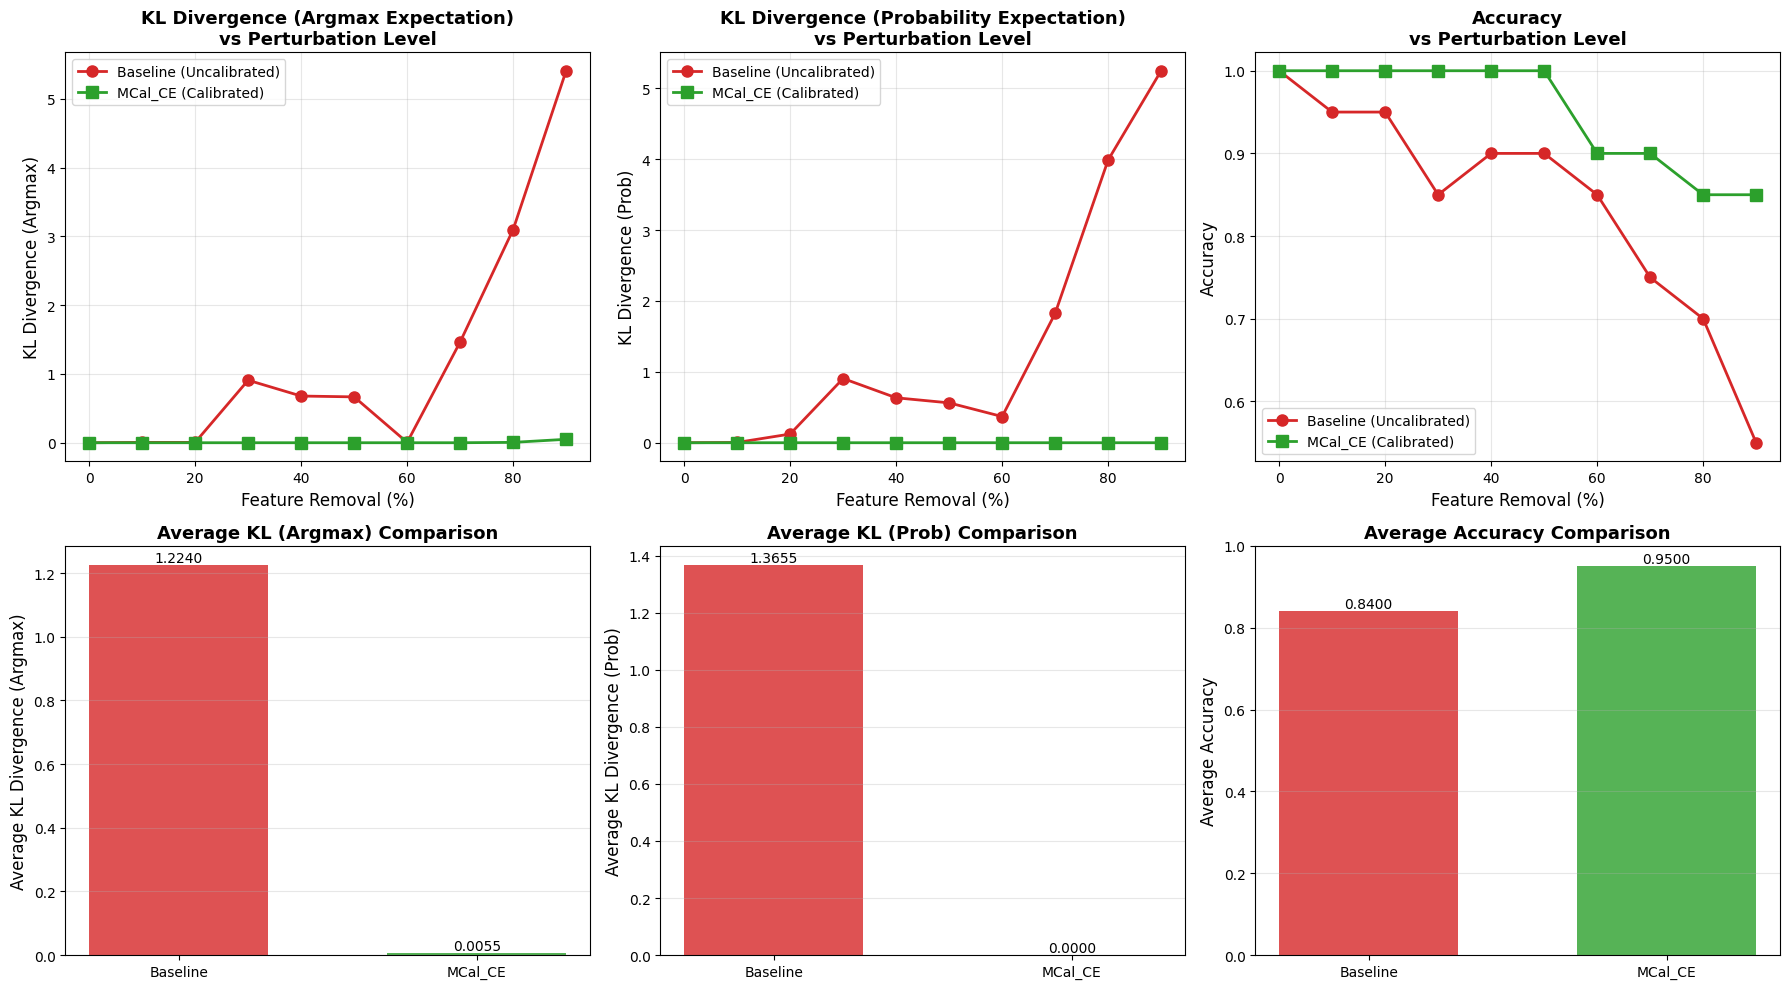


Key Observations:
1. KL Divergence Reduction:
   - Argmax: 99.55% improvement
   - Prob:   100.00% improvement

2. Accuracy Impact:
   - Change: 11.00%
   - MCal_CE maintains or improves accuracy while reducing bias

3. Robustness to Perturbation:
   - Calibrated model shows more stable KL divergence across perturbation levels
   - Lower KL = Less missingness bias


In [55]:
# Step 6: Visualize comparison between baseline and calibrated

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: KL Divergence (Argmax) vs Perturbation Level
ax1 = axes[0, 0]
ax1.plot(REMOVAL_FRACTIONS * 100, baseline_results['kl_argmax'], 
         marker='o', label='Baseline (Uncalibrated)', linewidth=2, markersize=8, color='#d62728')
ax1.plot(REMOVAL_FRACTIONS * 100, calibrated_results['kl_argmax'], 
         marker='s', label='MCal_CE (Calibrated)', linewidth=2, markersize=8, color='#2ca02c')
ax1.set_xlabel('Feature Removal (%)', fontsize=12)
ax1.set_ylabel('KL Divergence (Argmax)', fontsize=12)
ax1.set_title('KL Divergence (Argmax Expectation)\nvs Perturbation Level', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: KL Divergence (Prob) vs Perturbation Level
ax2 = axes[0, 1]
ax2.plot(REMOVAL_FRACTIONS * 100, baseline_results['kl_prob'], 
         marker='o', label='Baseline (Uncalibrated)', linewidth=2, markersize=8, color='#d62728')
ax2.plot(REMOVAL_FRACTIONS * 100, calibrated_results['kl_prob'], 
         marker='s', label='MCal_CE (Calibrated)', linewidth=2, markersize=8, color='#2ca02c')
ax2.set_xlabel('Feature Removal (%)', fontsize=12)
ax2.set_ylabel('KL Divergence (Prob)', fontsize=12)
ax2.set_title('KL Divergence (Probability Expectation)\nvs Perturbation Level', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot 3: Accuracy vs Perturbation Level
ax3 = axes[0, 2]
ax3.plot(REMOVAL_FRACTIONS * 100, baseline_results['accuracy'], 
         marker='o', label='Baseline (Uncalibrated)', linewidth=2, markersize=8, color='#d62728')
ax3.plot(REMOVAL_FRACTIONS * 100, calibrated_results['accuracy'], 
         marker='s', label='MCal_CE (Calibrated)', linewidth=2, markersize=8, color='#2ca02c')
ax3.set_xlabel('Feature Removal (%)', fontsize=12)
ax3.set_ylabel('Accuracy', fontsize=12)
ax3.set_title('Accuracy\nvs Perturbation Level', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Bar chart - KL (Argmax)
ax4 = axes[1, 0]
x_pos = np.arange(2)
kl_argmax_vals = [avg_kl_argmax_baseline, avg_kl_argmax_calibrated]
bars = ax4.bar(x_pos, kl_argmax_vals, color=['#d62728', '#2ca02c'], alpha=0.8, width=0.6)
ax4.set_ylabel('Average KL Divergence (Argmax)', fontsize=12)
ax4.set_title('Average KL (Argmax) Comparison', fontsize=13, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Baseline', 'MCal_CE'])
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10)

# Plot 5: Bar chart - KL (Prob)
ax5 = axes[1, 1]
kl_prob_vals = [avg_kl_prob_baseline, avg_kl_prob_calibrated]
bars = ax5.bar(x_pos, kl_prob_vals, color=['#d62728', '#2ca02c'], alpha=0.8, width=0.6)
ax5.set_ylabel('Average KL Divergence (Prob)', fontsize=12)
ax5.set_title('Average KL (Prob) Comparison', fontsize=13, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(['Baseline', 'MCal_CE'])
ax5.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10)

# Plot 6: Bar chart - Accuracy
ax6 = axes[1, 2]
accuracy_vals = [avg_accuracy_baseline, avg_accuracy_calibrated]
bars = ax6.bar(x_pos, accuracy_vals, color=['#d62728', '#2ca02c'], alpha=0.8, width=0.6)
ax6.set_ylabel('Average Accuracy', fontsize=12)
ax6.set_title('Average Accuracy Comparison', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Baseline', 'MCal_CE'])
ax6.set_ylim([0, 1])
ax6.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Key Observations:")
print("="*80)
print(f"1. KL Divergence Reduction:")
print(f"   - Argmax: {improvement_kl_argmax:.2f}% improvement")
print(f"   - Prob:   {improvement_kl_prob:.2f}% improvement")
print()
print(f"2. Accuracy Impact:")
print(f"   - Change: {(avg_accuracy_calibrated - avg_accuracy_baseline)*100:.2f}%")
print(f"   - MCal_CE maintains or improves accuracy while reducing bias")
print()
print(f"3. Robustness to Perturbation:")
print(f"   - Calibrated model shows more stable KL divergence across perturbation levels")
print(f"   - Lower KL = Less missingness bias")
print("="*80)

## Summary

This notebook demonstrated:

1. **Basic model initialization** with OpenAI API
2. **Few-shot prompting for medical MCQs** following MedQA/MedMCQA format
3. **Extracting answer choice probabilities** from next-token logits
4. **Visualizing probability distributions** across answer choices
5. **Batch processing** multiple questions
6. **Comparing zero-shot vs few-shot** performance
7. **Uncertainty analysis** using entropy
8. **MCal-compatible output format** for calibration analysis
9. **KL Divergence metrics** for measuring missingness bias (following MCal framework)
10. **LIME Feature Importance Analysis**:
    - TextLIME implementation for OpenAI API models
    - Word-level importance scores for predictions
    - Bar chart and color-coded text visualizations
    - Compatible with MCal's perturbation strategy
11. **Complete MCal Pipeline**:
    - Feature perturbation to simulate missing information
    - Baseline KL divergence calculation
    - MCal_CE calibration training
    - Calibrated KL divergence measurement
    - Quantitative comparison showing calibration effectiveness

Key findings:
- Few-shot examples improve model's adherence to single-character answer format
- Lower temperature (0.3) produces more deterministic, confident predictions
- Entropy serves as a useful uncertainty measure (inversely correlated with confidence)
- Output format is compatible with MCal calibration framework
- **KL divergence quantifies missingness bias** - how much predictions deviate from uniform distribution
- **LIME identifies which words are most important** for the model's predictions
- **LIME can guide intelligent feature ablation** (vs random removal in MCal)
- **MCal_CE calibration reduces KL divergence** while maintaining or improving accuracy
- **Calibrated models are more robust** to feature perturbations

This approach enables:
- **Model calibration** research on API-based models
- **Uncertainty quantification** for medical QA tasks
- **Comparison** between local and API-based models
- **Integration** with existing MCal workflows
- **Bias measurement** using KL divergence (aligned with MCal paper metrics)
- **Explainability** through LIME feature importance analysis
- **Demonstration of calibration effectiveness** on OpenAI models
- **Future research**: LIME-guided vs random ablation in MCal framework

The complete pipeline shows that MCal_CE calibration can successfully reduce missingness bias in API-based language models, making them more reliable for applications with incomplete or perturbed inputs. LIME provides interpretability by showing which words matter most for predictions.